##Import Libraries

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

##Load Dataset

In [6]:
url1 = "https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/housing_train_dataset.csv"
url2 = "https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/housing_test_dataset.csv"

train_df = pd.read_csv(url1)
test_df = pd.read_csv(url2)

In [7]:
train_df.head()

,ID,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,14197,-117.03,32.71,33,3126,627.0,2300,623,3.2596,103000,NEAR OCEAN
1,8268,-118.16,33.77,49,3382,787.0,1314,756,3.8125,382100,NEAR OCEAN
2,17446,-120.48,34.66,4,1897,331.0,915,336,4.1563,172600,NEAR OCEAN
3,14266,-117.11,32.69,36,1421,367.0,1418,355,1.9425,93400,NEAR OCEAN
4,2272,-119.80,36.78,43,2382,431.0,874,380,3.5542,96500,INLAND


In [9]:
test_df.head()

,ID,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,20047,-119.01,36.06,25,1505,NaN,1392,359,1.6812,INLAND
1,3025,-119.46,35.14,30,2943,NaN,1565,584,2.5313,INLAND
2,15664,-122.44,37.80,52,3830,NaN,1310,963,3.4801,NEAR BAY
3,20485,-118.72,34.28,17,3051,NaN,1705,495,5.7376,<1H OCEAN
4,9815,-121.93,36.62,34,2351,NaN,1063,428,3.7250,NEAR OCEAN


##Shape

In [10]:
print("Training Shape :", train_df.shape)
print("Testing Shape :", test_df.shape)

Training Shape : (16512, 11)
Testing Shape : (4128, 10)


##Information

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  16512 non-null  int64  
 1   longitude           16512 non-null  float64
 2   latitude            16512 non-null  float64
 3   housing_median_age  16512 non-null  int64  
 4   total_rooms         16512 non-null  int64  
 5   total_bedrooms      16512 non-null  float64
 6   population          16512 non-null  int64  
 7   households          16512 non-null  int64  
 8   median_income       16512 non-null  float64
 9   median_house_value  16512 non-null  int64  
 10  ocean_proximity     16512 non-null  object 
dtypes: float64(4), int64(6), object(1)
memory usage: 1.4+ MB


##Statistical Summary

In [12]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,16512.0,10312.052931,5969.605185,2.0000,5150.7500,10339.5000,15477.250000,20640.0000
longitude,16512.0,-119.582290,2.005654,-124.3500,-121.8100,-118.5100,-118.010000,-114.3100
latitude,16512.0,35.643149,2.136665,32.5500,33.9300,34.2600,37.720000,41.9500
housing_median_age,16512.0,28.608285,12.602499,1.0000,18.0000,29.0000,37.000000,52.0000
total_rooms,16512.0,2642.004784,2174.646744,2.0000,1454.0000,2129.0000,3160.000000,39320.0000
total_bedrooms,16512.0,538.496851,419.007096,1.0000,296.7500,437.0000,647.000000,6445.0000
population,16512.0,1426.453004,1137.056380,3.0000,789.0000,1167.0000,1726.000000,35682.0000
households,16512.0,499.986919,380.967964,1.0000,280.0000,410.0000,606.000000,6082.0000
median_income,16512.0,3.880754,1.904294,0.4999,2.5667,3.5458,4.773175,15.0001
median_house_value,16512.0,207194.693738,115622.626448,14999.0000,119800.0000,179850.0000,265125.000000,500001.0000


##Missing Values

In [13]:
train_df.isnull().sum().sort_values(ascending=False)

,0
ID,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


##Duplicate Records

In [14]:
train_df.duplicated().sum()

np.int64(0)

##Unique Values

In [15]:
train_df.nunique()

,0
ID,16512
longitude,833
latitude,845
housing_median_age,52
total_rooms,5470
total_bedrooms,1816
population,3639
households,1706
median_income,10932
median_house_value,3675


##Target Distribution

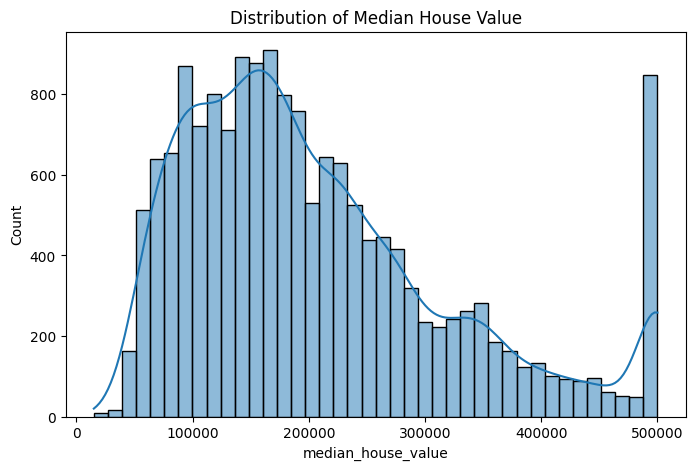

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["median_house_value"],
    kde=True,
    bins=40
)

plt.title("Distribution of Median House Value")
plt.show()

##Numerical Columns

In [17]:
num_cols = train_df.select_dtypes(include=np.number).columns
num_cols

Index(['ID', 'longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

##Categorical Columns

In [18]:
cat_cols = train_df.select_dtypes(include="object").columns
cat_cols

Index(['ocean_proximity'], dtype='object')

##Univariate Analysis

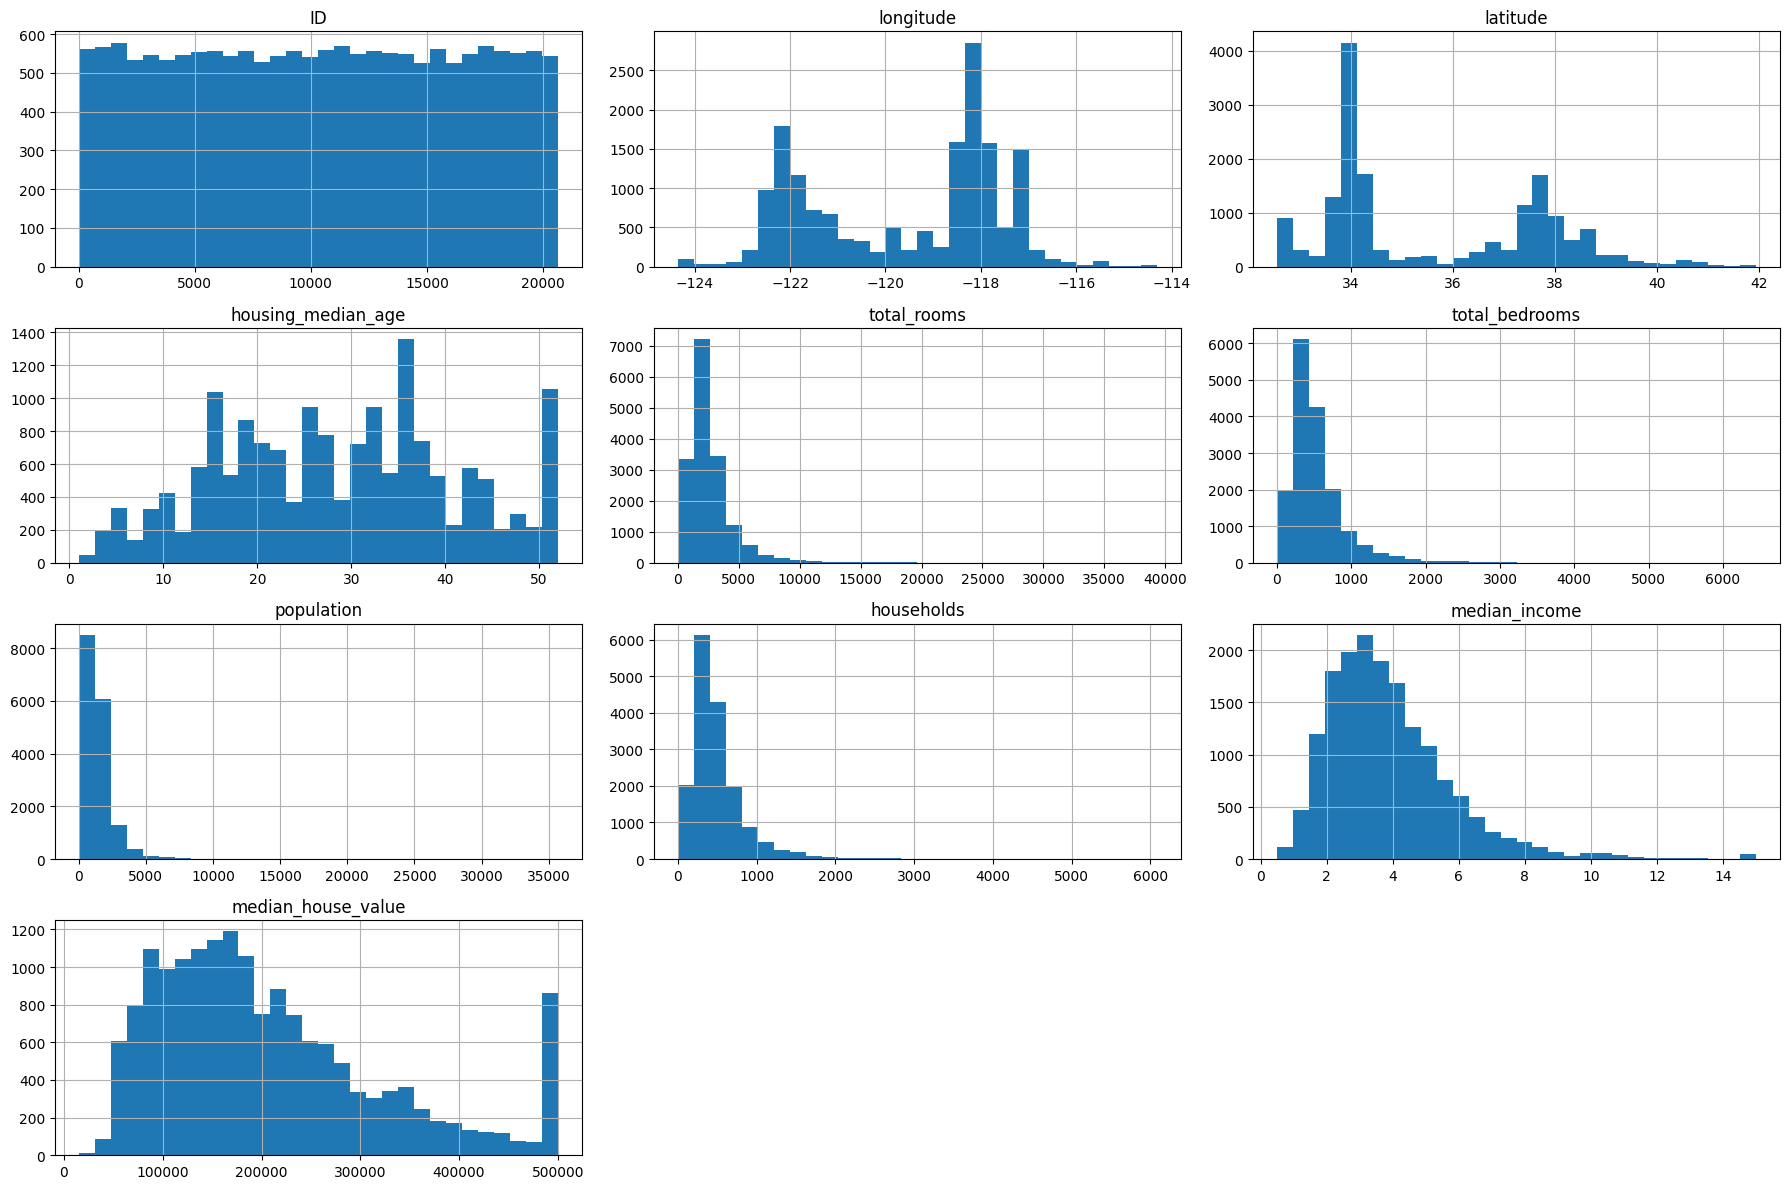

In [19]:
train_df[num_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

###Boxplots

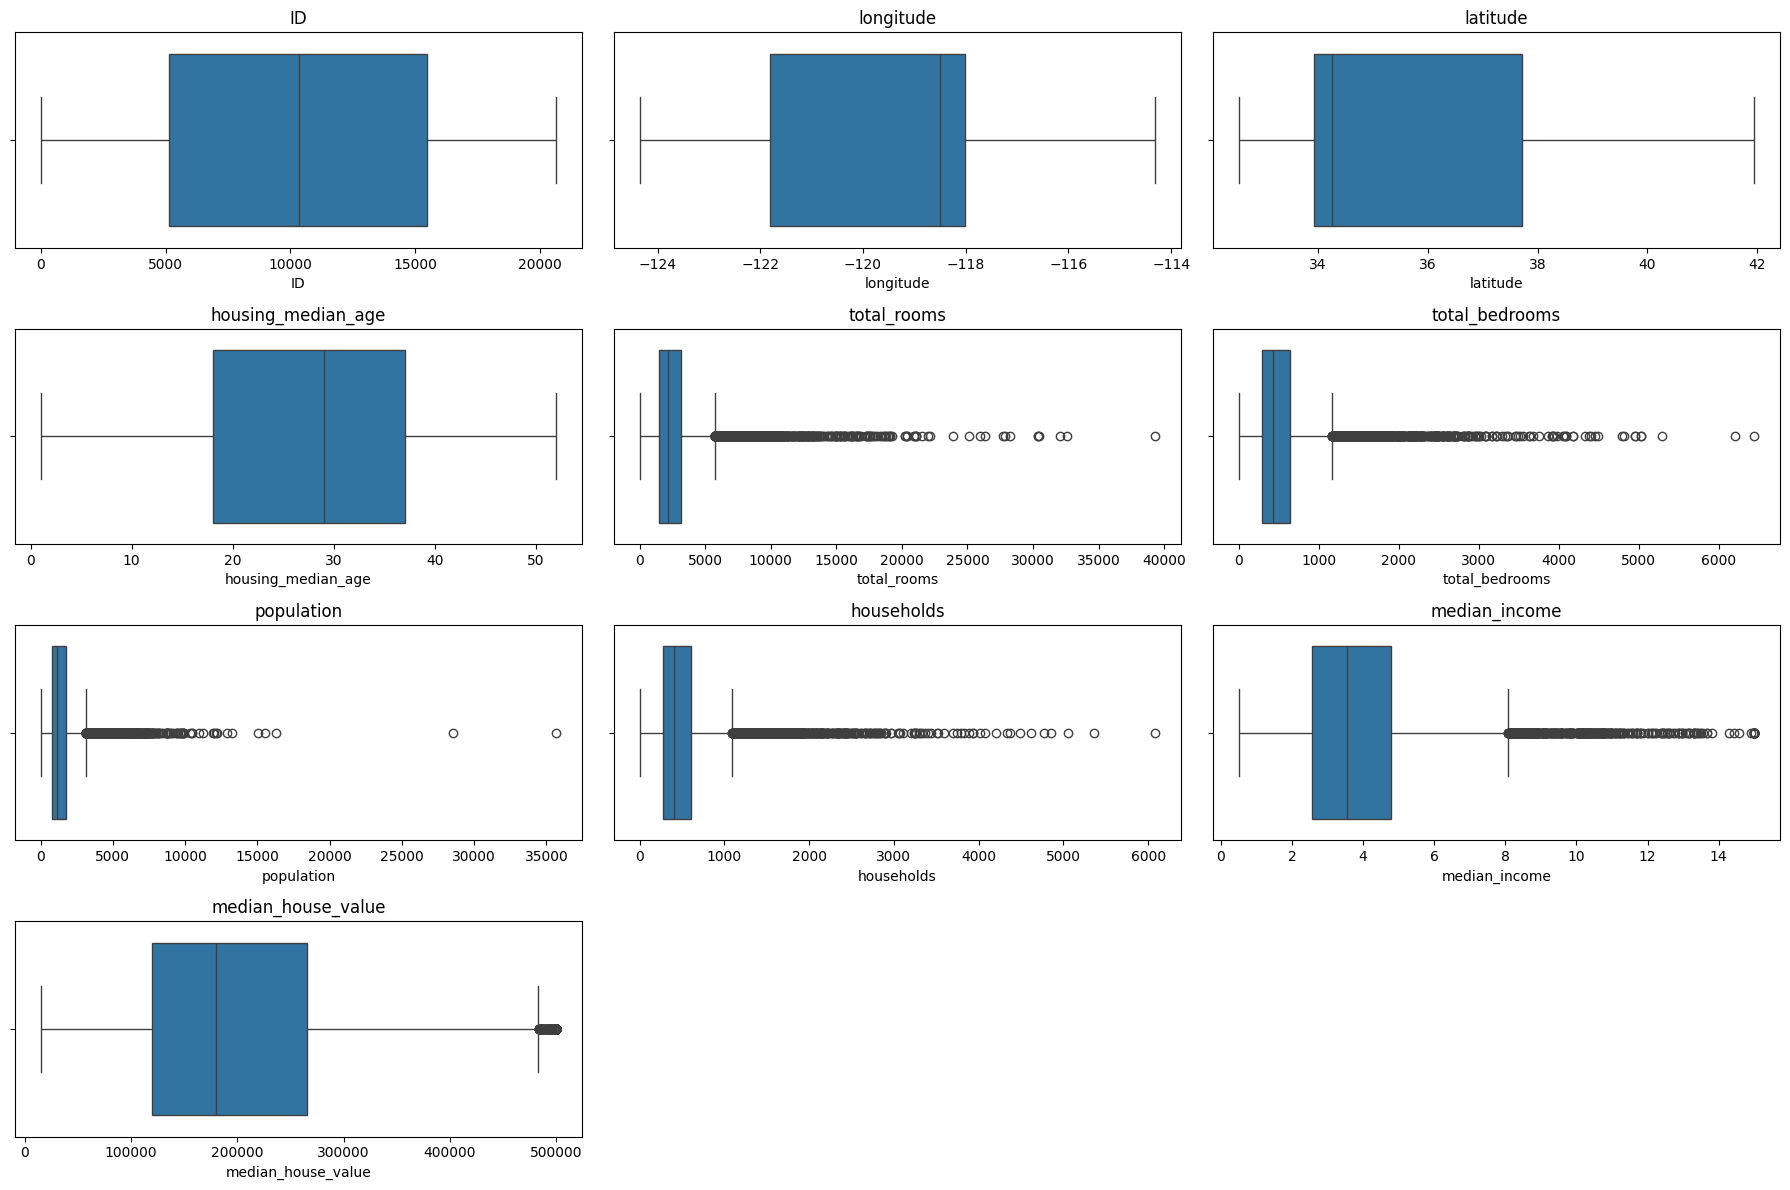

In [20]:
plt.figure(figsize=(18,12))

for i,col in enumerate(num_cols):

    plt.subplot(4,3,i+1)

    sns.boxplot(x=train_df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

##Categorical Distribution

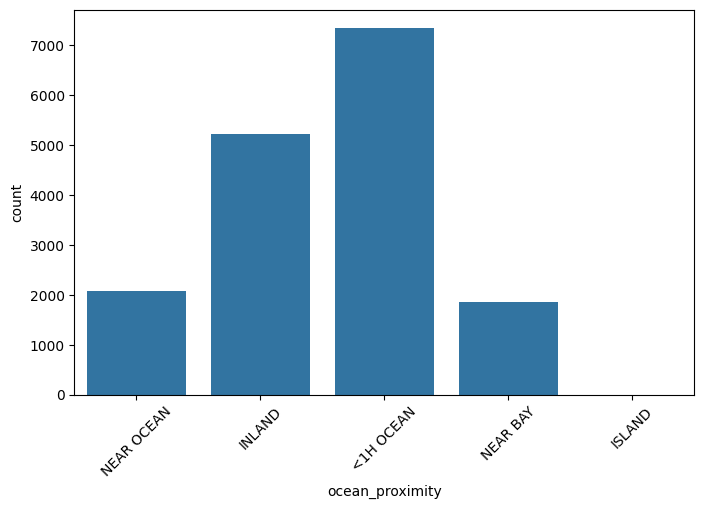

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="ocean_proximity"
)

plt.xticks(rotation=45)

plt.show()

##Correlation Matrix

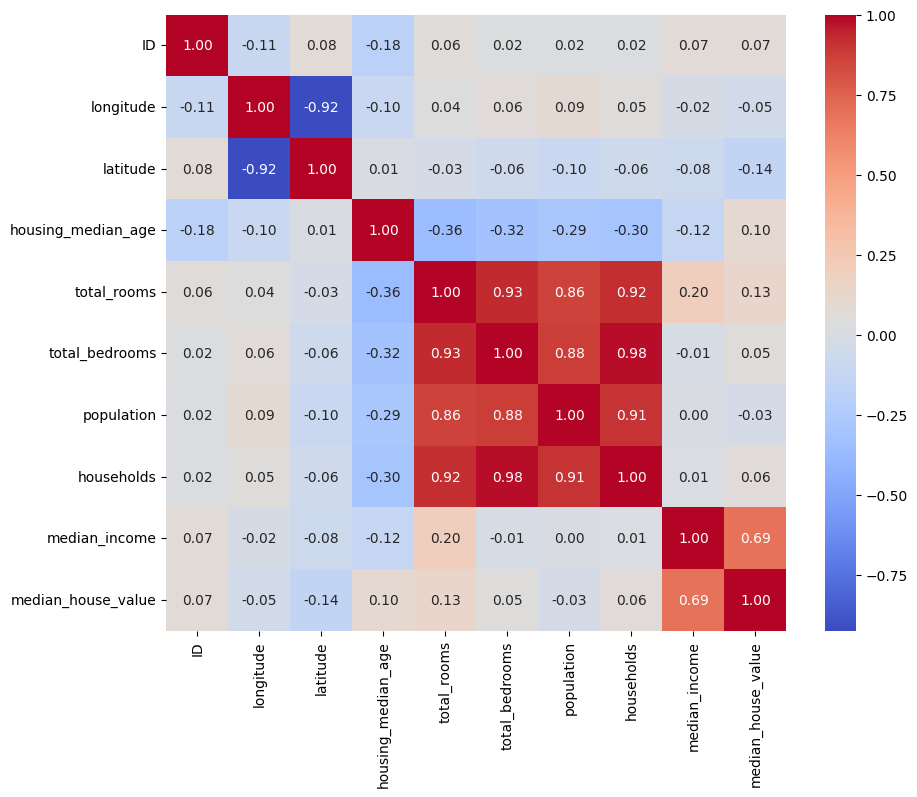

In [22]:
plt.figure(figsize=(10,8))

corr = train_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

##Correlation with Target

In [23]:
corr["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.690647
total_rooms,0.133989
housing_median_age,0.103706
ID,0.069769
households,0.063714
total_bedrooms,0.047980
population,-0.026032
longitude,-0.046349
latitude,-0.142983


##Pairplot (important variables)

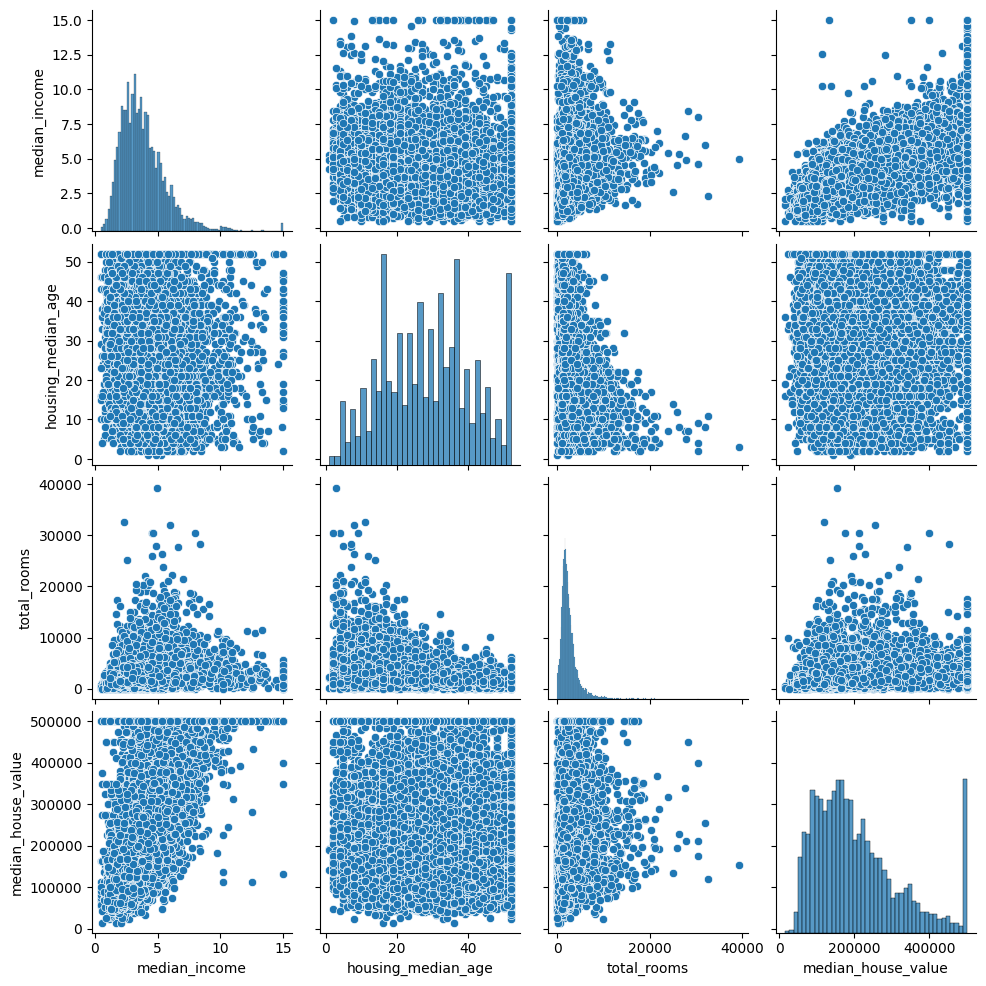

In [24]:
important = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "median_house_value"
]

sns.pairplot(train_df[important])

plt.show()

##Scatter Plot

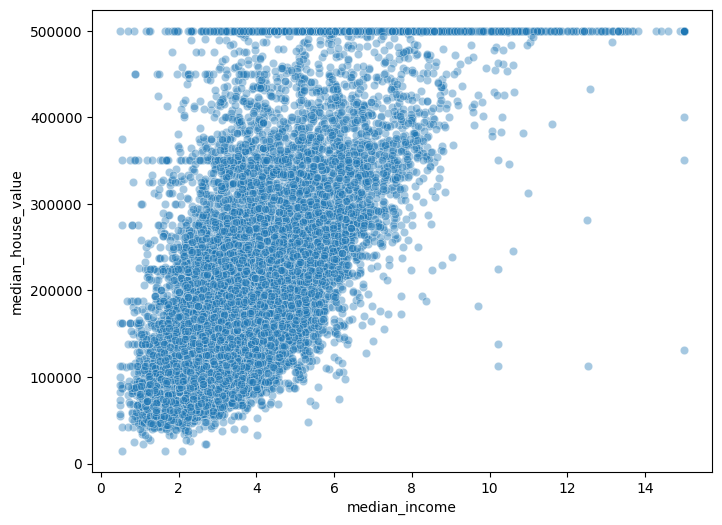

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=train_df,
    x="median_income",
    y="median_house_value",
    alpha=0.4
)

plt.show()

##Latitude vs Longitude

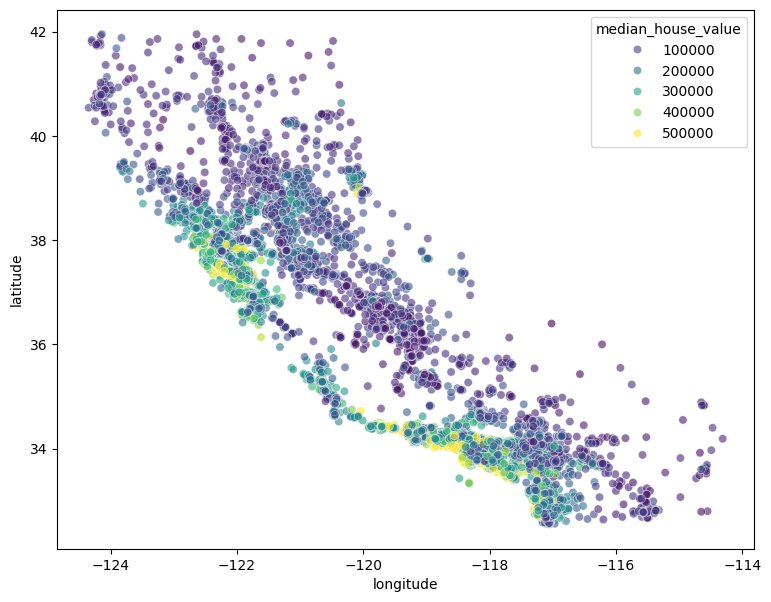

In [26]:
plt.figure(figsize=(9,7))

sns.scatterplot(
    data=train_df,
    x="longitude",
    y="latitude",
    hue="median_house_value",
    palette="viridis",
    alpha=0.6
)

plt.show()

##Ocean Proximity vs PriceOcean Proximity vs Price

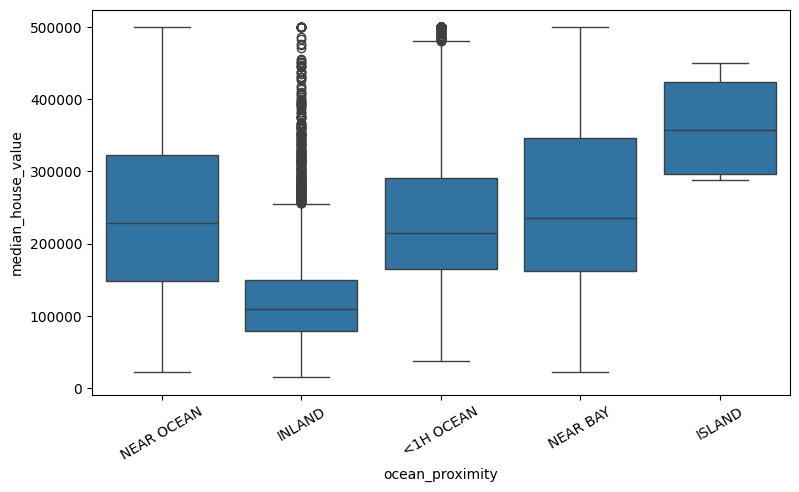

In [27]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=train_df,
    x="ocean_proximity",
    y="median_house_value"
)

plt.xticks(rotation=30)

plt.show()

##Feature Engineering

In [28]:
for df in [train_df, test_df]:

    df["rooms_per_household"] = (
        df["total_rooms"] / df["households"]
    )

    df["bedrooms_per_room"] = (
        df["total_bedrooms"] / df["total_rooms"]
    )

    df["population_per_household"] = (
        df["population"] / df["households"]
    )

In [29]:
train_df.head()

,ID,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,14197,-117.03,32.71,33,3126,627.0,2300,623,3.2596,103000,NEAR OCEAN,5.017657,0.200576,3.691814
1,8268,-118.16,33.77,49,3382,787.0,1314,756,3.8125,382100,NEAR OCEAN,4.473545,0.232703,1.738095
2,17446,-120.48,34.66,4,1897,331.0,915,336,4.1563,172600,NEAR OCEAN,5.645833,0.174486,2.723214
3,14266,-117.11,32.69,36,1421,367.0,1418,355,1.9425,93400,NEAR OCEAN,4.002817,0.258269,3.994366
4,2272,-119.80,36.78,43,2382,431.0,874,380,3.5542,96500,INLAND,6.268421,0.180940,2.300000


##Feature Engineering(Copy DataFrames)

In [30]:
train = train_df.copy()
test = test_df.copy()

##Create New Features

In [31]:
for df in [train, test]:

    df["rooms_per_household"] = df["total_rooms"] / df["households"]

    df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

    df["population_per_household"] = df["population"] / df["households"]

## Check Newly Created Features

In [32]:
train[
    [
        "rooms_per_household",
        "bedrooms_per_room",
        "population_per_household"
    ]
].head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,5.017657,0.200576,3.691814
1,4.473545,0.232703,1.738095
2,5.645833,0.174486,2.723214
3,4.002817,0.258269,3.994366
4,6.268421,0.180940,2.300000


##Train/Test Split

In [33]:
X = train.drop(columns=["median_house_value"])
y = train["median_house_value"]

In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Preprocessing Pipeline

In [35]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_features.remove("ID")

categorical_features = ["ocean_proximity"]

In [36]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [37]:
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [39]:
X_train_processed = preprocessor.fit_transform(X_train)

X_valid_processed = preprocessor.transform(X_valid)

X_test_processed = preprocessor.transform(test)


In [40]:
print(X_train_processed.shape)
print(X_valid_processed.shape)
print(X_test_processed.shape)

(13209, 16)
(3303, 16)
(4128, 16)


##KNN Regression

In [41]:
knn = KNeighborsRegressor()

###Grid Search

In [50]:
knn_params = {
    "n_neighbors": [3,5,7,9,11,13,15,17,19,21],
    "weights": ["uniform","distance"],
    "metric": ["euclidean","manhattan","minkowski"],
    "p": [1,2]
}

In [51]:
grid_knn = GridSearchCV(
    knn,
    knn_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_knn.fit(
    X_train_processed,
    y_train
)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='r2')

In [52]:
print(grid_knn.best_params_)

{'metric': 'manhattan', 'n_neighbors': 13, 'p': 1, 'weights': 'distance'}


In [53]:
best_knn = grid_knn.best_estimator_

knn_pred = best_knn.predict(
    X_valid_processed
)

##Evaluation Function

In [54]:
def evaluate_model(name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    print(f"Model : {name}")
    print(f"R2 Score : {r2:.4f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")

    return r2, mse, rmse

In [55]:
knn_metrics = evaluate_model(
    "KNN",
    y_valid,
    knn_pred
)

Model : KNN
R2 Score : 0.7534
MSE : 3402983779.65
RMSE : 58335.10


##Predicted vs Actual Plot

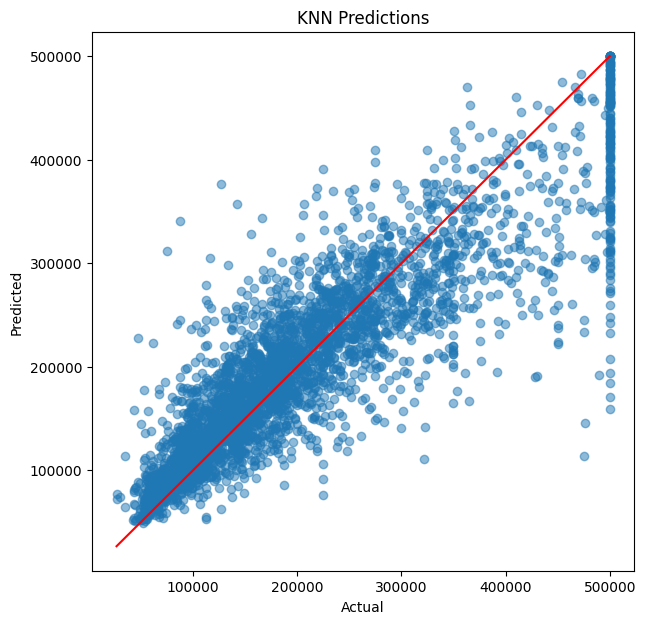

In [56]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_valid,
    knn_pred,
    alpha=0.5
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("KNN Predictions")

plt.show()

##Residual Plot

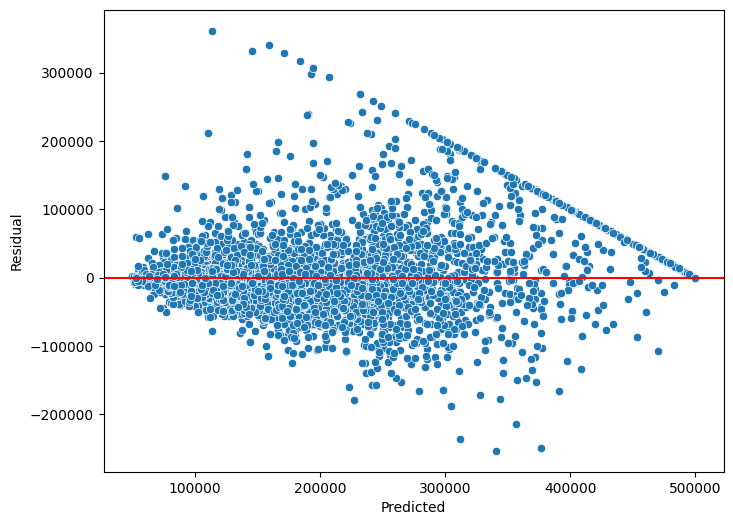

In [57]:
residuals = y_valid - knn_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=knn_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.show()

##Cross Validation

In [58]:
cv_scores = cross_val_score(
    best_knn,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
)

print(cv_scores)

[0.73709144 0.73994628 0.73465631 0.72815883 0.72353507]


In [59]:
print("Average CV Score :", cv_scores.mean())

Average CV Score : 0.7326775838817494


### KNN Summary

After hyperparameter tuning, KNN achieved an R² score of **0.7534** on the validation dataset.

The model generalized well, as confirmed through 5-fold cross-validation.

Although KNN produced strong baseline results, more advanced regression models such as SVR and Decision Tree are expected to achieve better predictive performance.

##Support Vector Regressor (SVR)

In [108]:
from sklearn.compose import TransformedTargetRegressor

####Create the model

In [109]:
svr = TransformedTargetRegressor(
    regressor=SVR(),
    transformer=StandardScaler()
)

##Hyperparameter Grid

In [110]:
svr_params = {
    "regressor__C": [50, 100],
    "regressor__epsilon": [0.1],
    "regressor__gamma": ["scale"]
}

##Grid Search

In [ ]:
grid_svr = GridSearchCV(
    estimator=svr,
    param_grid=svr_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_svr.fit(X_train_processed, y_train)

##Predictions

In [ ]:
best_svr = grid_svr.best_estimator_

svr_pred = best_svr.predict(X_valid_processed)

evaluate_model("SVR", y_valid, svr_pred)

##Decision Tree Regression

##Hyperparameter Grid

In [81]:
dt_params = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

##GridSearchCV

In [82]:
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_dt.fit(
    X_train_processed,
    y_train
)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

##Best Parameters

In [86]:
print("Best Parameters:")
print(grid_dt.best_params_)

print("\nBest CV Score:")
print(grid_dt.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Best CV Score:
0.7182030234660357


##Best Model

In [87]:
best_dt = grid_dt.best_estimator_

# Predictions

In [88]:
dt_pred = best_dt.predict(
    X_valid_processed
)

##Evaluation

In [89]:
dt_metrics = evaluate_model(
    "Decision Tree",
    y_valid,
    dt_pred
)

Model : Decision Tree
R2 Score : 0.7244
MSE : 3803327872.47
RMSE : 61671.13


##Predicted vs Actual

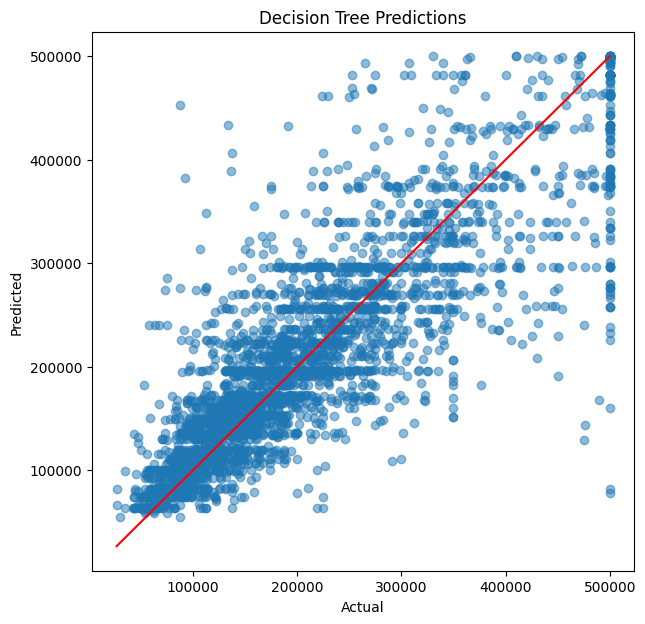

In [90]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_valid,
    dt_pred,
    alpha=0.5
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Decision Tree Predictions")

plt.show()

##Residual Plot

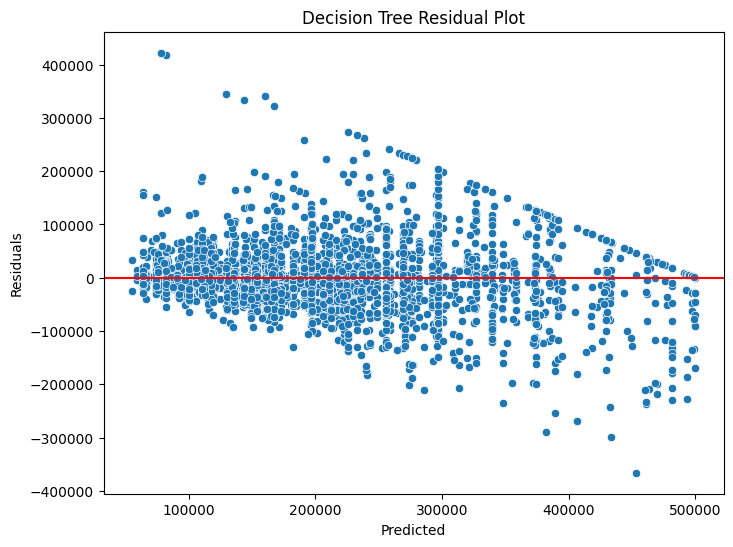

In [91]:
residuals = y_valid - dt_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=dt_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Decision Tree Residual Plot")

plt.show()

##Cross Validation

In [92]:
dt_cv = cross_val_score(
    best_dt,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(dt_cv)

print()

print("Average CV Score:", dt_cv.mean())

[0.72734058 0.72310698 0.71914402 0.71551658 0.70590696]

Average CV Score: 0.7182030234660357


##Feature Importance ⭐

In [93]:
feature_names = (
    numeric_features +
    list(
        preprocessor.named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(categorical_features)
    )
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
7,median_income,0.548132
12,ocean_proximity_INLAND,0.164400
10,population_per_household,0.118548
0,longitude,0.051676
1,latitude,0.042173
2,housing_median_age,0.033937
8,rooms_per_household,0.014843
9,bedrooms_per_room,0.010220
6,households,0.005482
3,total_rooms,0.003341


## Plot Feature Importance

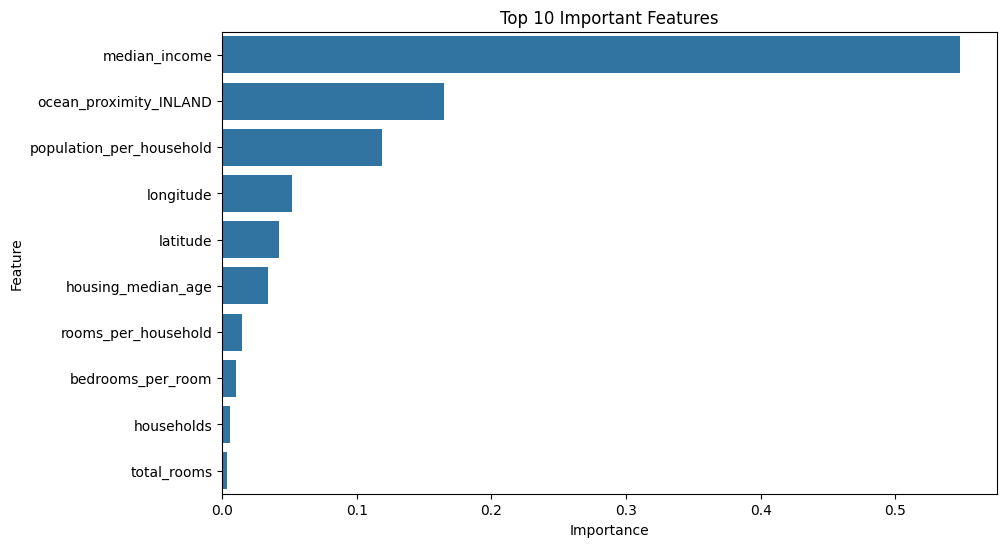

In [94]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

##Model Comparison

In [95]:
comparison = pd.DataFrame({
    "Model": ["KNN", "SVR", "Decision Tree"],
    "R2 Score": [knn_metrics[0], svr_metrics[0], dt_metrics[0]],
    "MSE": [knn_metrics[1], svr_metrics[1], dt_metrics[1]],
    "RMSE": [knn_metrics[2], svr_metrics[2], dt_metrics[2]]
})

comparison.sort_values("R2 Score", ascending=False)

,Model,R2 Score,MSE,RMSE
0,KNN,0.753405,3.402984e+09,58335.099037
2,Decision Tree,0.724394,3.803328e+09,61671.126733
1,SVR,0.279965,9.936402e+09,99681.500789


##Visualize Model Performance

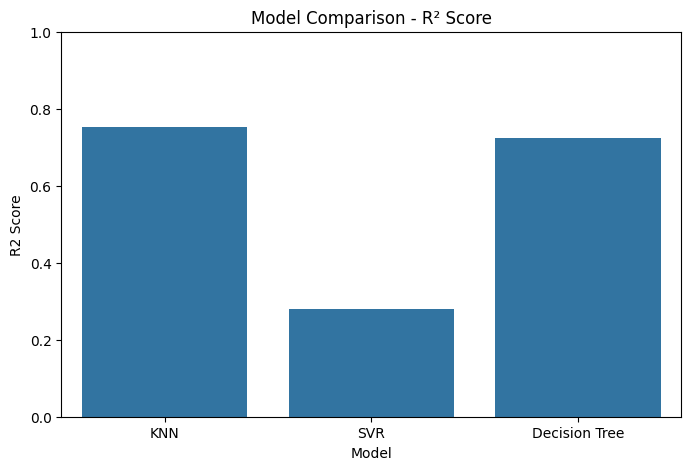

In [96]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison - R² Score")
plt.ylim(0,1)

plt.show()

##RMSE Comparison

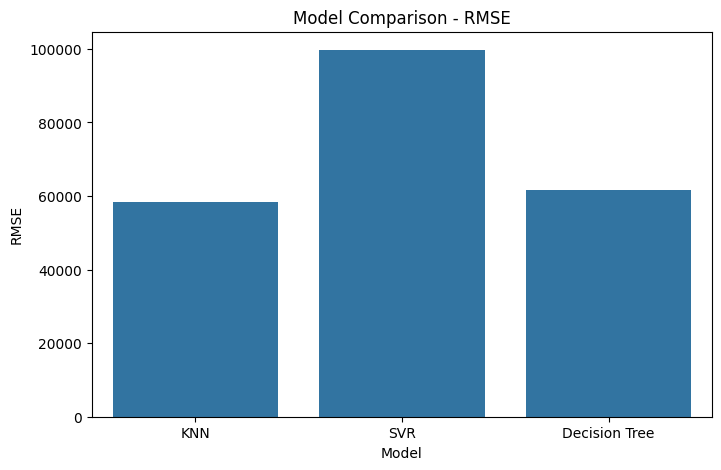

In [97]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison - RMSE")

plt.show()

##Select the Best Model

In [98]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: KNN


##Predict on Test Dataset

In [99]:
test_predictions = best_knn.predict(X_test_processed)

##Output DataFrame

In [100]:
output_df = pd.DataFrame({
    "ID": test["ID"],
    "median_house_value": test_predictions
})

output_df.head()

,ID,median_house_value
0,20047,55703.455729
1,3025,75392.464118
2,15664,346150.737995
3,20485,275107.243777
4,9815,292786.381719


##Inspect Predictions

In [102]:
output_df.describe()

,ID,median_house_value
count,4128.000000,4128.000000
mean,10354.288275,201760.701813
std,5913.960911,92220.742184
min,1.000000,49655.366399
25%,5211.000000,130787.270206
50%,10256.500000,190448.458406
75%,15483.500000,255347.957183
max,20639.000000,500001.000000


## Distribution of Predictions

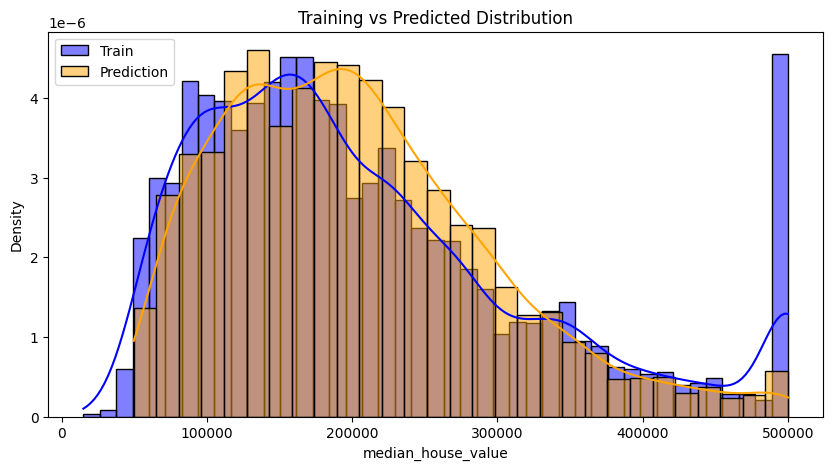

In [103]:
plt.figure(figsize=(10,5))

sns.histplot(
    y,
    color="blue",
    label="Train",
    kde=True,
    stat="density",
    alpha=0.5
)

sns.histplot(
    test_predictions,
    color="orange",
    label="Prediction",
    kde=True,
    stat="density",
    alpha=0.5
)

plt.legend()

plt.title("Training vs Predicted Distribution")

plt.show()

##Model Insights

## Model Insights

- KNN achieved the highest R² score among all evaluated models.
- SVR significantly underperformed despite feature scaling and hyperparameter tuning.
- Decision Tree captured feature importance effectively but generalized less well than KNN.
- Median Income was the most influential feature, followed by Inland proximity and Population per Household.

##Conclusion

# Conclusion

This project developed multiple machine learning models to predict California housing prices.

Key findings:

- Missing values were handled using median imputation.
- Numerical variables were standardized.
- Three new engineered features improved the representation of housing characteristics.
- Three regression models (KNN, SVR, and Decision Tree) were trained and evaluated.
- KNN achieved the highest validation performance (R² = 0.7534), making it the selected model for final predictions.
- Feature importance analysis highlighted Median Income as the strongest predictor of housing prices.

Future improvements include experimenting with ensemble methods such as Random Forest, Gradient Boosting, XGBoost, and LightGBM to further improve predictive performance.